In [1]:
%load_ext autoreload

%autoreload 1

# custom imports

from ete3 import Tree
from ete3.treeview import faces, AttrFace, TextFace, TreeStyle, NodeStyle, CircleFace, RectFace

import ete3 as ete3
ete3.__version__

import os

os.environ['QT_QPA_PLATFORM']='offscreen'

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import glob

In [3]:
import subprocess
import os
import glob

In [4]:
from itertools import tee

In [5]:
from IPython.display import display, clear_output

In [6]:
from scipy.stats import spearmanr

In [7]:
ete3.__version__

'3.1.3'

# Outline

Code for constructing a basic phylogenetic model

In [8]:
# load gtdb
gtdb_md = pd.read_csv('/data/mhoffert/genomes/GTDB_r214.1/bac120_metadata.tsv.gz', sep='\t', index_col=0)

/tmp/ipykernel_2502211/866121538.py:2: DtypeWarning: Columns (61,63,65,74,82,83) have mixed types. Specify dtype option on import or set low_memory=False.
  gtdb_md = pd.read_csv('/data/mhoffert/genomes/GTDB_r214.1/bac120_metadata.tsv.gz', sep='\t', index_col=0)


In [9]:
# load temperature data
temp_data = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_filtered.tsv.gz', sep='\t', index_col=0)
temp_data.head()

,Position,Contacts at 4.5 Å,SASA,uid,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,bbsc_internal_hbonds,...,temp,mean_temp,seq_length,bitscore,C,L,N,P,max_structure_length,lid_bitscore
0,94.0,11.358289,52.616491,GB_GCA_000376885.1,-454.076,1.278,10.765,2.648,124.0,21.0,...,37.0,37.0,187,178.2,90.0,48.0,42.0,6.0,24,0.0
1,108.0,11.125581,49.464040,GB_GCA_000016765.1,-450.126,1.316,10.730,2.697,132.0,30.0,...,30.0,30.0,215,175.3,116.0,49.0,43.0,6.0,23,52.3
2,119.5,11.289720,49.538232,GB_GCA_000242235.1,-419.604,1.327,10.981,2.842,128.0,22.0,...,37.0,37.0,214,192.2,117.0,48.0,42.0,6.0,24,59.2
3,105.5,11.276190,50.018080,GB_GCA_000283575.1,-452.738,1.390,10.905,2.771,129.0,20.0,...,30.0,30.0,210,168.7,112.0,48.0,43.0,6.0,24,58.3
4,91.0,11.359116,51.483049,GB_GCA_001054945.1,-431.800,1.243,10.768,2.669,117.0,20.0,...,37.0,37.0,181,192.9,88.0,44.0,42.0,6.0,21,0.0


In [10]:
genome2temp = temp_data.set_index('uid')[['mean_temp']]
genome2temp['bin'] = pd.cut(genome2temp['mean_temp'], np.linspace(10, 86, 16))
grouped = genome2temp.groupby('bin').apply(lambda x: x.sample(np.min([20, len(x)])))

/tmp/ipykernel_2502211/336467697.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = genome2temp.groupby('bin').apply(lambda x: x.sample(np.min([20, len(x)])))


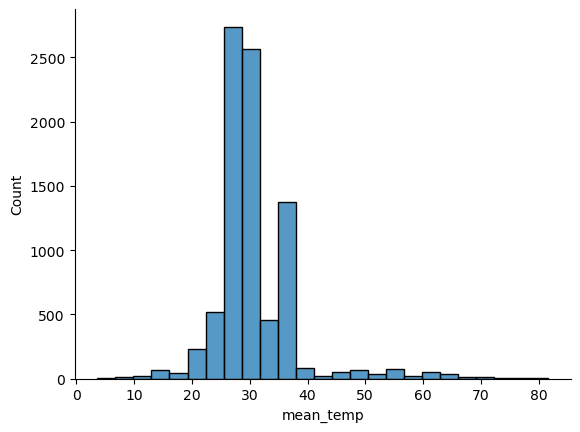

In [11]:
# fig, ax = 
sns.histplot(genome2temp['mean_temp'], bins=25)
sns.despine()


## Load tree

In [12]:
gtdb_full = Tree('/data/mhoffert/genomes/GTDB_r214.1/bac120_r214.tree', format=1, quoted_node_names=True)

## Phylogenetic model
1. Exclude random nodes from the tree
2. Predict nearest
3. Exclude large group from the tree
4. Predict nearest

In [13]:
# prune to OGT dataset
gtdb_pruned = gtdb_full.copy()
gtdb_pruned.prune(genome2temp.index, preserve_branch_length=True)

In [14]:
gtdb_pruned.describe()

Number of leaf nodes:	8532
Total number of nodes:	17063
Rooted:	Yes
Most distant node:	RS_GCF_005061465.1
Max. distance:	2.994207


In [15]:
# get a sample
sample = genome2temp.sample(frac=0.2)
# pruned_test = gtdb_pruned.copy()

# pruned_test.prune(genome2temp[~genome2temp.index.isin(sample.index)].index)
# pruned_test.describe()

In [16]:
len(sample)

1706

In [17]:
# construct test tree
pruned_test = gtdb_full.copy()
pruned_test.prune(genome2temp[~genome2temp.index.isin(sample.index)].index)
pruned_test.describe()

Number of leaf nodes:	6826
Total number of nodes:	13651
Rooted:	Yes
Most distant node:	RS_GCF_900660525.1
Max. distance:	1.953261


In [18]:
def get_closest_leaf_exclude(tree, target_leaf_name, test_set, min_distance=0):
    '''
    function for getting the closest leaf to a leaf while excluding a test set
    '''
    
    # get target
    target = tree & target_leaf_name
    # iterate over leaves and get distances
    candidates = [
        (leaf, target.get_distance(leaf))
        for leaf in tree.iter_leaves()
        if leaf.name not in test_set and leaf.name != target_leaf_name
    ]
    # if there's nothing in the set 
    if not candidates:
        return None, None
    
    candidates = [c for c in candidates if c[1] > min_distance]
    
    # return closest leaf
    closest_leaf, min_dist = min(candidates, key=lambda x: x[1])
    return closest_leaf, min_dist


In [19]:
# tests of get closest leaf function
# Tree with varying branch lengths
t = Tree("((A:1.1,B:3.5):0.87,(C:5.1,(D:1.56,E:0.03):1.1):1.6);")
print(t)


      /-A
   /-|
  |   \-B
--|
  |   /-C
   \-|
     |   /-D
      \-|
         \-E


In [20]:
# Basic test: closest to A (1 away from B, >6 from everyone else)
leaf, dist = get_closest_leaf_exclude(t, "A", {"A"})
print(leaf, dist)
assert leaf.name == "B"
assert abs(dist - 4.6) < 1e-6

# Exclude B too → closest is D or E (~9 distance)
leaf, dist = get_closest_leaf_exclude(t, "A", {"A", "B"})
print(leaf, dist)
assert leaf.name in {"D", "E", "C"}

# Exclude everything except one leaf
leaf, dist = get_closest_leaf_exclude(t, "A", {"A", "B", "C", "D"})
print(leaf, dist)
assert leaf.name == "E"

# All other leaves excluded → should return None
leaf, dist = get_closest_leaf_exclude(t, "A", {"A", "B", "C", "D", "E"})
print(leaf, dist)
assert leaf is None
assert dist is None

# Closest leaf to leaf in middle of a cherry
leaf, dist = get_closest_leaf_exclude(t, "D", {"D", "E"})
print(leaf, dist)
assert leaf.name in {"A", "B", "C"}

print("All tests passed.")


--B 4.6

--E 4.7

--E 4.7
None None

--A 6.2299999999999995
All tests passed.


In [21]:
dists = [0, 0.1, 0.5, 1]
phylo_accuracy = pd.DataFrame(columns=['nearest_temp', 'actual_temp', 'dist'], 
                              index=pd.MultiIndex.from_product([sample.index, dists,]))

for i, test_leaf in enumerate(sample.index):
    # if i % 10 == 0:
    display(i)
    clear_output(wait=True)
        
    test_node = gtdb_pruned.search_nodes(name=test_leaf)[0]
    
    for min_dist in dists:
        # look at closest non-testing node
        closest, dist = get_closest_leaf_exclude(gtdb_pruned, test_leaf, set(sample.index), min_dist)

        # closest = closest[closest[:, 1].astype(float) > 0.05]

        # print(closest)

        phylo_accuracy.loc[(test_node.name, min_dist), 'actual_temp'] = genome2temp.loc[test_node.name, 'mean_temp']
        phylo_accuracy.loc[(test_node.name, min_dist), 'nearest_temp'] = genome2temp.loc[closest.name, 'mean_temp']
        phylo_accuracy.loc[(test_node.name, min_dist), 'dist'] = dist
    
    

1705

In [41]:
from sklearn.metrics import mean_squared_error

CPU times: user 3.39 s, sys: 244 ms, total: 3.63 s
Wall time: 654 ms


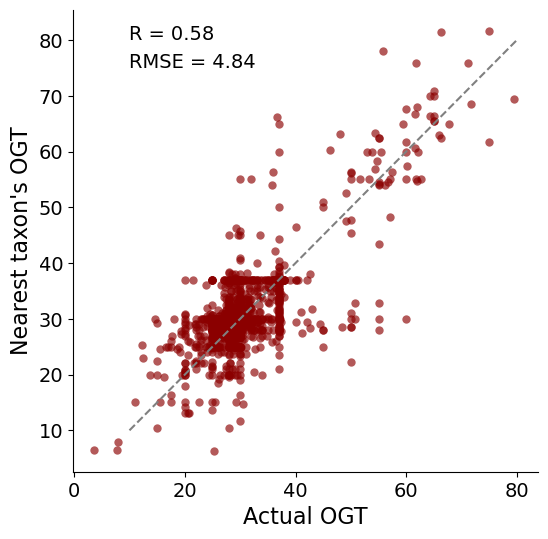

In [49]:
%%time

idx = pd.IndexSlice


fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=phylo_accuracy.loc[idx[:, 0], :],
                y='nearest_temp',
                x='actual_temp',
                linewidth=0,
                alpha=0.65, 
                # hue='dist', palette='gnuplot')
                color='darkred')
spr = spearmanr(phylo_accuracy.loc[idx[:, 0], :]['nearest_temp'], phylo_accuracy.loc[idx[:, 0], :]['actual_temp'])[0]

ax.annotate(f'R = {spr:.2f}', (10, 80), color='k', fontsize=14)
ax.annotate(f"RMSE = {np.sqrt(mean_squared_error(phylo_accuracy.loc[idx[:, 0], 'nearest_temp'], phylo_accuracy.loc[idx[:, 0], 'actual_temp'])):.2f}", (10, 75), color='k', fontsize=14)

plt.plot((10, 80), (10, 80), color='gray', linestyle='--')

sns.despine()
ax.set_ylabel('Nearest taxon\'s OGT', fontsize=16)
ax.set_xlabel('Actual OGT', fontsize=16)
plt.tick_params(labelsize=14)
# 
plt.savefig('./../data/figures/phylo_model_accuracy.png', dpi=400, bbox_inches='tight')
# 

In [23]:
from sklearn.metrics import mean_squared_error

In [24]:
np.sqrt(mean_squared_error(phylo_accuracy['nearest_temp'], phylo_accuracy['actual_temp']))

6.735227451462856

In [60]:
plotdf = phylo_accuracy.reset_index()

plotdf['RSE'] = ((plotdf['nearest_temp'] - plotdf['actual_temp']) ** 2).apply(lambda x: np.sqrt(x))

plotdf['x_label'] = plotdf['level_1'].map(dict((s, i) for s,i in zip(plotdf['level_1'].unique(), range(len(plotdf['level_1'].unique())))))

plotdf

,uid,level_1,nearest_temp,actual_temp,dist,RSE,x_label
0,RS_GCF_010093445.1,0.0,28.666667,31.166667,0.156726,2.500000,0
1,RS_GCF_010093445.1,0.1,28.666667,31.166667,0.156726,2.500000,1
2,RS_GCF_010093445.1,0.5,45.226887,31.166667,0.510962,14.060220,2
3,RS_GCF_010093445.1,1.0,33.333333,31.166667,1.045365,2.166667,3
4,RS_GCF_900639915.1,0.0,37.0,37.0,0.244541,0.000000,0
...,...,...,...,...,...,...,...
6819,RS_GCF_001981305.1,1.0,31.5,42.666667,1.002874,11.166667,3
6820,RS_GCF_000376945.1,0.0,34.166667,33.166667,0.446125,1.000000,0
6821,RS_GCF_000376945.1,0.1,34.166667,33.166667,0.446125,1.000000,1
6822,RS_GCF_000376945.1,0.5,28.5,33.166667,0.522301,4.666667,2


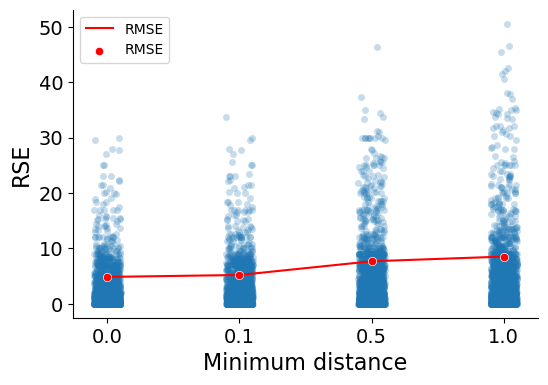

In [61]:
'''
Make a plot showing the phylogenetic accuracy of extrapolated data (y)
vs. a minimum distance threshold (x)
'''

fig, ax = plt.subplots(figsize=(6,4))

sns.stripplot(data=plotdf, x=plotdf['x_label'], y='RSE', zorder=0, alpha=0.25, linewidth=0)

sns.lineplot(data=plotdf.groupby('x_label').apply(lambda x: np.sqrt(mean_squared_error(x['nearest_temp'], x['actual_temp'])) ).reset_index(),
             x='x_label',
             y=0, color='r', zorder=1, label='RMSE')

sns.scatterplot(data=plotdf.groupby('x_label').apply(lambda x: np.sqrt(mean_squared_error(x['nearest_temp'], x['actual_temp'])) ).reset_index(),
             x='x_label',
             y=0, color='r', zorder=1, label='RMSE')

ax.set_xticks(range(len(plotdf['level_1'].unique())))
ax.set_xticklabels(plotdf['level_1'].unique())
plt.tick_params(labelsize=14)
ax.set_ylabel('RSE', fontsize=16)
ax.set_xlabel('Minimum distance', fontsize=16)
sns.despine()

plt.savefig('./../data/figures/20250620_pnn_dist_rse.png', dpi=400, bbox_inches='tight')

In [63]:
plotdf.groupby('x_label').apply(lambda x: np.sqrt(mean_squared_error(x['nearest_temp'], x['actual_temp'])) ).reset_index()

,x_label,0
0,0,4.841060
1,1,5.187131
2,2,7.662027
3,3,8.509072


#### Notes
Upward trend shows that taxa's OGTs are less similar as they diverge

In [27]:
phylo_accuracy.to_csv('./../data/phylogenetic_model/20250618_phylogenetic_accuracy.tsv.gz')

## Blocked phylogenetic model

In [35]:
# for each phylogenetic group, identify all non-phylum level 
leaves = [l.name for l in gtdb_pruned]
levels = [1, 2, 3]

tax_phylo_accuracy = pd.DataFrame(columns=['nearest_temp', 'actual_temp', 'tax_name', 'dist'], 
                              index=pd.MultiIndex.from_product([sample.index, levels]))

for level in levels:
    taxonomy = gtdb_md.loc[leaves, 'gtdb_taxonomy'].apply(lambda x: x.split(';')[level].split('__')[-1])
    
    for level_group in taxonomy.unique():
        exclude_set = taxonomy[taxonomy.eq(level_group)].index

        for i, test_leaf in enumerate(exclude_set):
            # if i % 10 == 0:
            display(i)
            clear_output(wait=True)

            test_node = gtdb_pruned.search_nodes(name=test_leaf)[0]

            # look at closest non-testing node
            closest, dist = get_closest_leaf_exclude(gtdb_pruned, test_leaf, set(exclude_set), 0)

            # save data
            tax_phylo_accuracy.loc[(test_node.name, level), 'actual_temp'] = genome2temp.loc[test_node.name, 'mean_temp']
            tax_phylo_accuracy.loc[(test_node.name, level), 'nearest_temp'] = genome2temp.loc[closest.name, 'mean_temp']
            tax_phylo_accuracy.loc[(test_node.name, level), 'dist'] = dist
            tax_phylo_accuracy.loc[(test_node.name, level), 'tax_name'] = level_group

0

In [56]:
plotdf = tax_phylo_accuracy.reset_index()

plotdf['RSE'] = ((plotdf['nearest_temp'] - plotdf['actual_temp']) ** 2).apply(lambda x: np.sqrt(x))

plotdf['x_label'] = plotdf['level_1'].map(dict((s, i) for s,i in zip(plotdf['level_1'].unique(), range(len(plotdf['level_1'].unique())))))

plotdf

,uid,level_1,nearest_temp,actual_temp,tax_name,dist,RSE,x_label
0,RS_GCF_010093445.1,1,66.227875,31.166667,Pseudomonadota,2.027417,35.061208,0
1,RS_GCF_010093445.1,2,25.0,31.166667,Gammaproteobacteria,1.767233,6.166667,1
2,RS_GCF_010093445.1,3,33.333333,31.166667,Xanthomonadales,1.045365,2.166667,2
3,RS_GCF_900639915.1,1,66.227875,37.0,Pseudomonadota,1.980083,29.227875,0
4,RS_GCF_900639915.1,2,25.0,37.0,Gammaproteobacteria,1.719899,12.000000,1
...,...,...,...,...,...,...,...,...
25591,RS_GCF_010091945.1,3,24.0,21.0,Leptolyngbyales,0.485544,3.000000,2
25592,RS_GCF_000007925.1,3,50.0,16.353119,PCC-6307,1.291124,33.646881,2
25593,RS_GCF_000316515.1,3,50.0,18.0,PCC-6307,0.98509,32.000000,2
25594,RS_GCF_001027545.1,3,60.333333,30.0,Endomicrobiales,1.899295,30.333333,2


In [57]:
plotdf #[ 'tax_level'].value_counts()

,uid,level_1,nearest_temp,actual_temp,tax_name,dist,RSE,x_label
0,RS_GCF_010093445.1,1,66.227875,31.166667,Pseudomonadota,2.027417,35.061208,0
1,RS_GCF_010093445.1,2,25.0,31.166667,Gammaproteobacteria,1.767233,6.166667,1
2,RS_GCF_010093445.1,3,33.333333,31.166667,Xanthomonadales,1.045365,2.166667,2
3,RS_GCF_900639915.1,1,66.227875,37.0,Pseudomonadota,1.980083,29.227875,0
4,RS_GCF_900639915.1,2,25.0,37.0,Gammaproteobacteria,1.719899,12.000000,1
...,...,...,...,...,...,...,...,...
25591,RS_GCF_010091945.1,3,24.0,21.0,Leptolyngbyales,0.485544,3.000000,2
25592,RS_GCF_000007925.1,3,50.0,16.353119,PCC-6307,1.291124,33.646881,2
25593,RS_GCF_000316515.1,3,50.0,18.0,PCC-6307,0.98509,32.000000,2
25594,RS_GCF_001027545.1,3,60.333333,30.0,Endomicrobiales,1.899295,30.333333,2


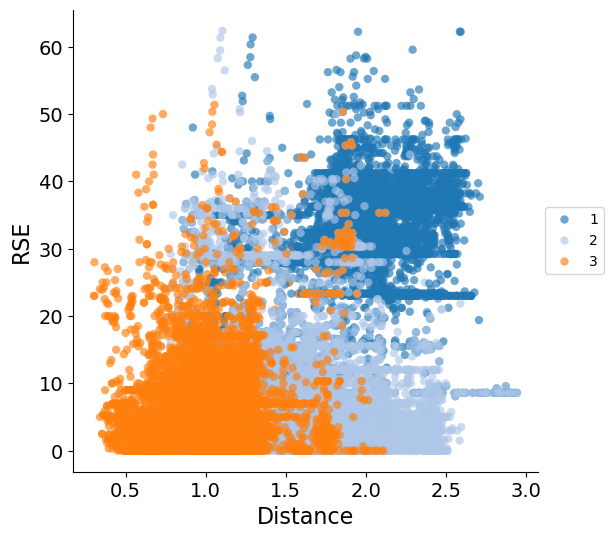

In [58]:
'''
Make a plot showing the phylogenetic accuracy of extrapolated data (y)
vs. a minimum distance threshold (x)
'''

fig, ax = plt.subplots(figsize=(6,6))

sns.scatterplot(data=plotdf, x='dist', y='RSE', hue='level_1', linewidth=0, alpha=0.65, palette='tab20')

lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# sns.stripplot(data=plotdf, x=plotdf['tax_name'], y='RSE', zorder=0, alpha=0.25, linewidth=0)

# sns.lineplot(data=plotdf.groupby('tax_name').apply(lambda x: np.sqrt(mean_squared_error(x['nearest_temp'], x['actual_temp'])) ).reset_index(),
#              x='tax_name',
#              y=0, color='r', zorder=1, label='RMSE')

# sns.scatterplot(data=plotdf.groupby('x_label').apply(lambda x: np.sqrt(mean_squared_error(x['nearest_temp'], x['actual_temp'])) ).reset_index(),
#              x='tax_name',
#              y=0, color='r', zorder=1, label='RMSE')

# ax.set_xticks(range(len(plotdf['level_1'].unique())))
# ax.set_xticklabels(plotdf['level_1'].unique())
plt.tick_params(labelsize=14)
ax.set_ylabel('RSE', fontsize=16)
ax.set_xlabel('Distance', fontsize=16)
sns.despine()

plt.savefig('./../data/figures/20250620_pnn_taxlevels.png', dpi=400, bbox_inches='tight')

In [95]:
def get_n_clades(tree, n):
    """
    Cut the tree into `n` large, roughly equally sized clades.
    Returns a list of lists of leaf names (one list per block).
    """
    nodes = [tree]
    while len(nodes) < n:
        # Choose the largest node (with most leaves) to split
        nodes = sorted(nodes, key=lambda x: len(x.get_leaves()), reverse=True)
        to_split = nodes.pop(0)
        if to_split.is_leaf() or len(to_split.children) < 2:
            nodes.append(to_split)
            break  # Can't split further
        # Split by children
        nodes.extend(to_split.children)
    
    # Make blocks from leaves in each node
    # blocks = []
    return [(node, [leaf.name for leaf in node.get_leaves()]) for node in nodes[:n]]

# def get_n_clades(tree, n):
#     """
#     Select `n` clades by extracting all nodes at a specific level in the tree.
#     If more than `n` nodes are found, the largest `n` (by leaf count) are returned.
#     If fewer than `n` nodes exist at that level, deeper levels are checked.
#     """
#     def nodes_at_level(root, level):
#         """Recursively collect nodes at a given level (root is level 0)."""
#         if level == 0:
#             return [root]
#         nodes = []
#         for child in root.children:
#             nodes.extend(nodes_at_level(child, level - 1))
#         return nodes

#     level = 1
#     while True:
#         nodes = nodes_at_level(tree, level)
#         # Filter internal nodes only
#         nodes = [node for node in nodes if not node.is_leaf()]
#         if len(nodes) >= n:
#             break
#         level += 1
#         if level > tree.get_farthest_leaf()[1]:
#             raise ValueError("Tree does not have enough internal nodes to produce that many clades.")

#     # Pick top-n nodes with the most leaves
#     nodes = sorted(nodes, key=lambda node: len(node.get_leaves()), reverse=True)[:n]
#     # blocks = [[leaf.name for leaf in node.get_leaves()] for node in nodes]
#     return [(node, [leaf.name for leaf in node.get_leaves()]) for node in nodes[:n]]

In [96]:
# Create 5 phylogenetic blocks
blocks = get_n_clades(gtdb_pruned, 5)

# Output the blocks
for i, block in enumerate(blocks):
    print(f"Block {i+1}: {len(block[1])}")

Block 1: 3903
Block 2: 72
Block 3: 50
Block 4: 3641
Block 5: 866


In [105]:
phylo_accuracy = pd.DataFrame(columns=['nearest_temp', 'actual_temp', 'block'])
for block_num, block in enumerate(blocks):
    
    # get tree without block in it
    block_tree = gtdb_pruned.copy()
    block_tree.prune([l.name for l in gtdb_pruned.get_leaves() if not l.name in block[1]])
    
    # for each leaf in the block
    for i, test_leaf in enumerate(block[1]):
        if i % 10 == 0:
            display(i)
            clear_output(wait=True)
        
        # get the closest node: always the closest node to the parent of the block's common ancestor
        closest = block_tree.search_nodes(name=block[0].up.name)[0].get_closest_leaf()[0].name
        
        phylo_accuracy.loc[test_leaf, 'actual_temp'] = genome2temp.loc[test_leaf, 'mean_temp']
        phylo_accuracy.loc[test_leaf, 'nearest_temp'] = genome2temp.loc[closest, 'mean_temp']
        phylo_accuracy.loc[test_leaf, 'block'] = block_num
    
    

860

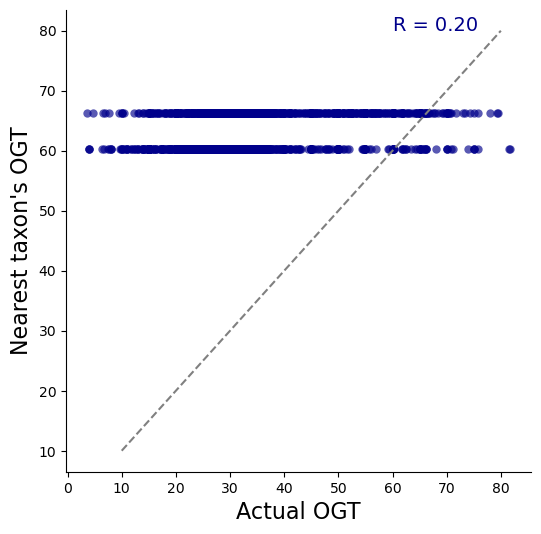

In [107]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(data=phylo_accuracy,
                y='nearest_temp',
                x='actual_temp',
                linewidth=0,
                alpha=0.65, color='darkblue')
spr = spearmanr(phylo_accuracy['nearest_temp'], phylo_accuracy['actual_temp'])[0]
ax.annotate(f'R = {spr:.2f}', (60, 80), color='darkblue', fontsize=14)

sns.despine()
ax.set_ylabel('Nearest taxon\'s OGT', fontsize=16)
ax.set_xlabel('Actual OGT', fontsize=16)
plt.plot((10, 80), (10, 80), color='gray', linestyle='--')
